In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Load dataset and add column names
data = pd.read_csv("data.csv", names = ["x1", "x2", "label"])

#Separate class
red = data[data["label"] == 0]
blue = data[data["label"] == 1]

data.head()

,x1,x2,label
0,0.78051,-0.063669,1
1,0.28774,0.291390,1
2,0.40714,0.178780,1
3,0.29230,0.421700,1
4,0.50922,0.352560,1


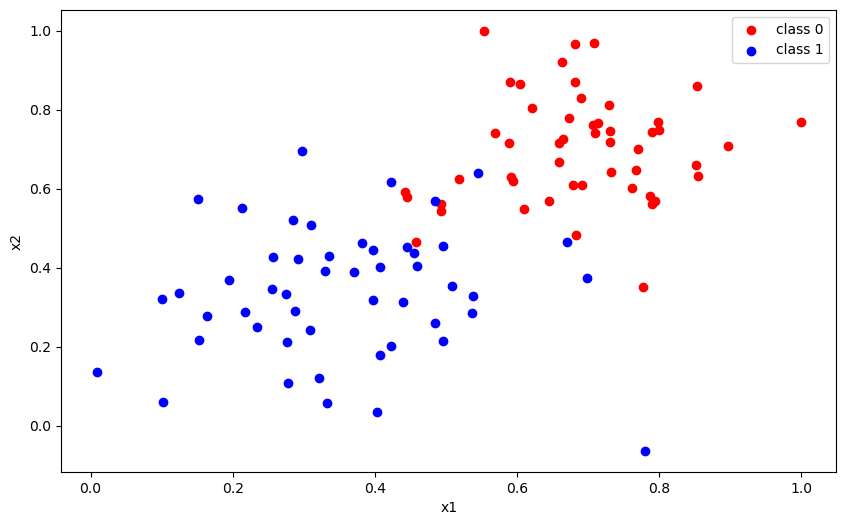

In [6]:
#plot
plt.figure(figsize=(10,6))
plt.scatter(red["x1"], red["x2"], color="red", label = "class 0")
plt.scatter(blue["x1"], blue["x2"], color="blue", label = "class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()

In [7]:
#Decision boundary
def plot_line(w1, w2, b, color='black', linestyle='-'):
    x_vals = np.linspace(0, 1, 100)
    
    # Avoid division by zero
    if w2 != 0:
        y_vals = -(w1 * x_vals + b) / w2
        plt.plot(x_vals, y_vals, color=color, linestyle=linestyle)

In [8]:
#heuristic approach
def heuristic(data, learning_rate, epochs):
    #ensure reproducibility
    np.random.seed(49)
    w1, w2 = np.random.randn(2)
    b = np.random.randn()
    plt.figure(figsize=(10,6))
    plt.scatter(red["x1"], red["x2"], color="red", label = "class 0")
    plt.scatter(blue["x1"], blue["x2"], color="blue", label = "class 1")
    #initial separation line
    plot_line(w1, w2, b, color="red", linestyle="--")
    #training
    for epoch in range(epochs):
        for _, row in data.iterrows():
            x1, x2, y = row["x1"], row["x2"], row["label"]
            #predict
            z = w1*x1 + w2*x2 + b
            y_hat = 1 if z >=0 else 0
            #update misclassified
            if y == 1 and y_hat == 0:
                w1 += learning_rate * x1
                w2 += learning_rate * x2
                b  += learning_rate
            elif y == 0 and y_hat == 1:
                w1 -= learning_rate * x1
                w2 -= learning_rate * x2
                b  -= learning_rate
        #subsequent lines
        plot_line(w1, w2, b, color="green", linestyle="--")
    #Final line
    plot_line(w1, w2, b, color="black", linestyle="-")
    plt.title("Solution boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.ylim(0,1)
    plt.show()

    return w1, w2, b

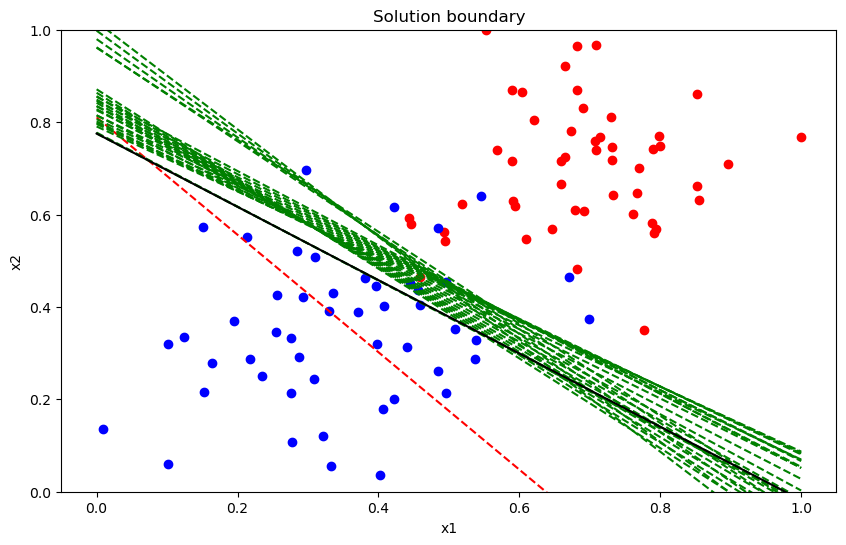

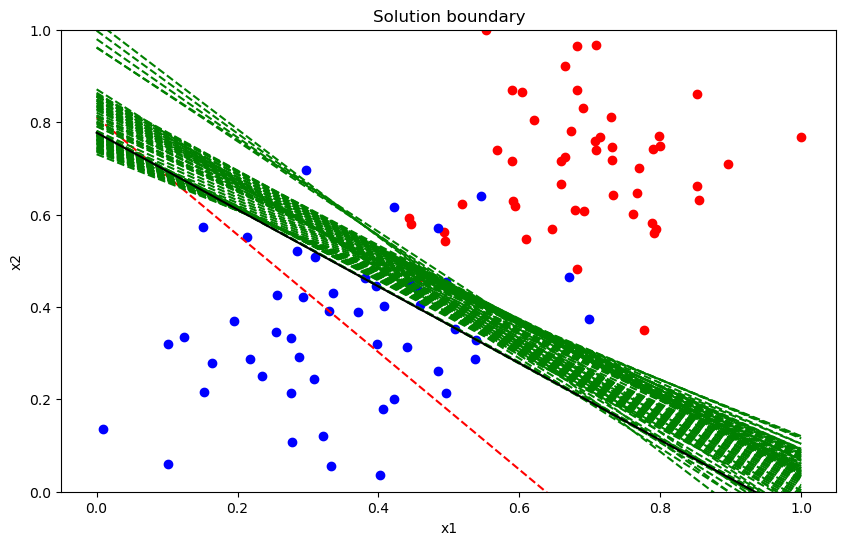

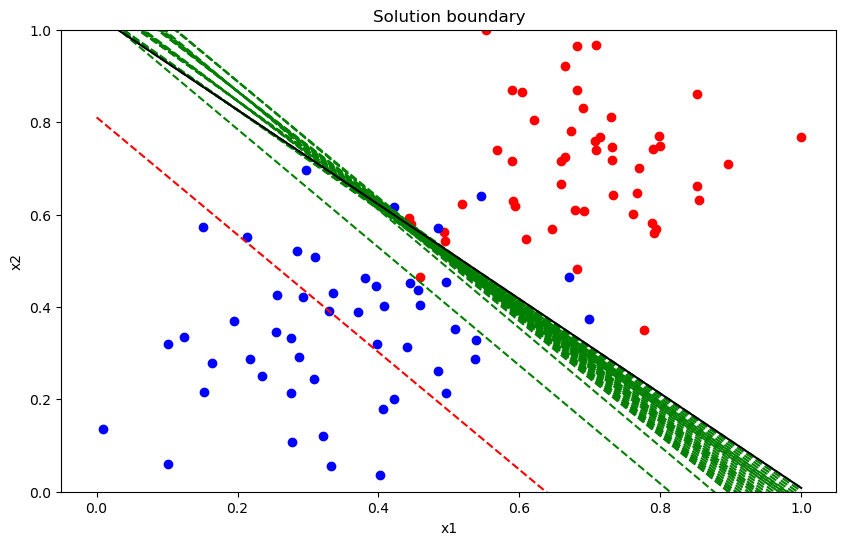

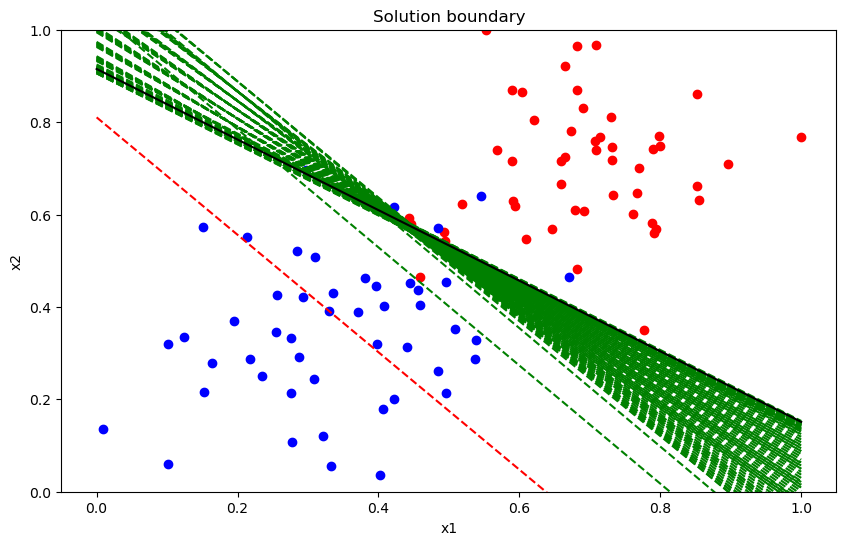

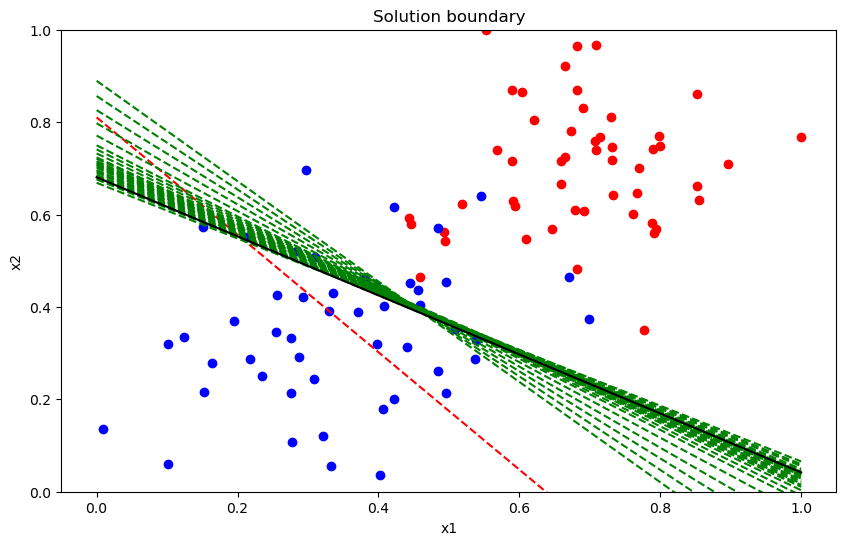

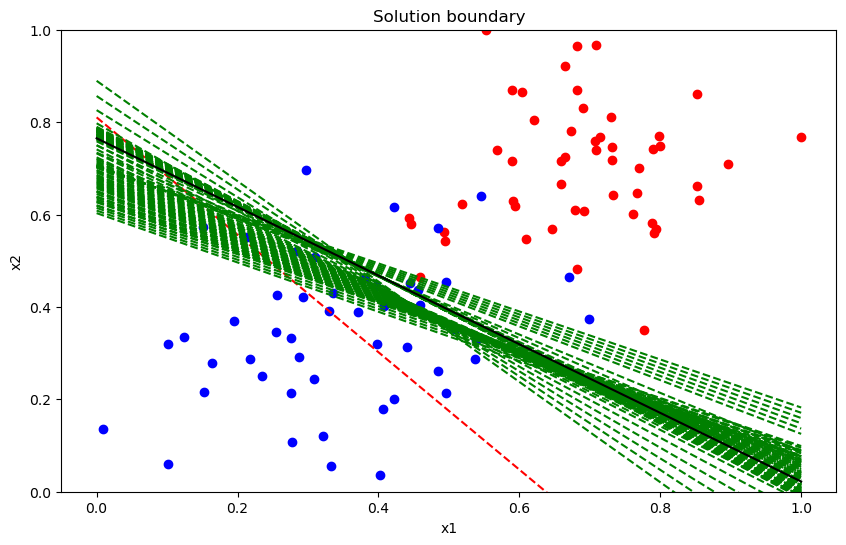

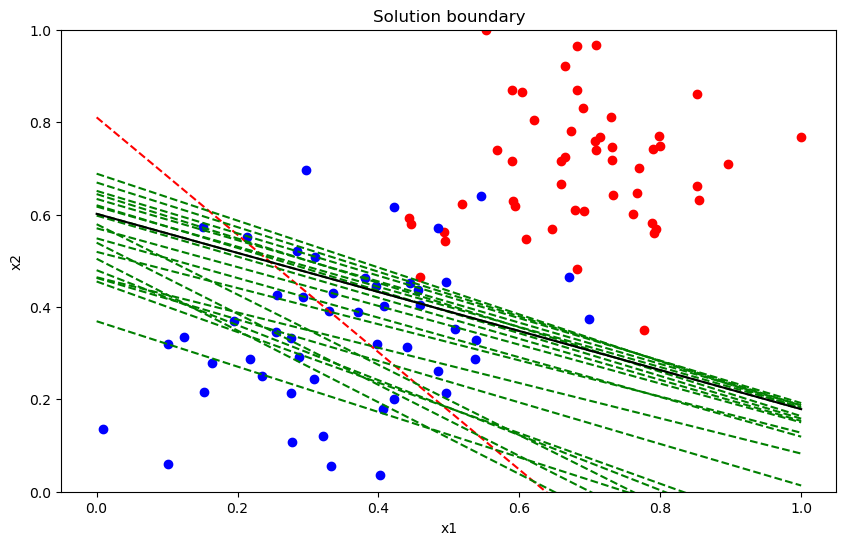

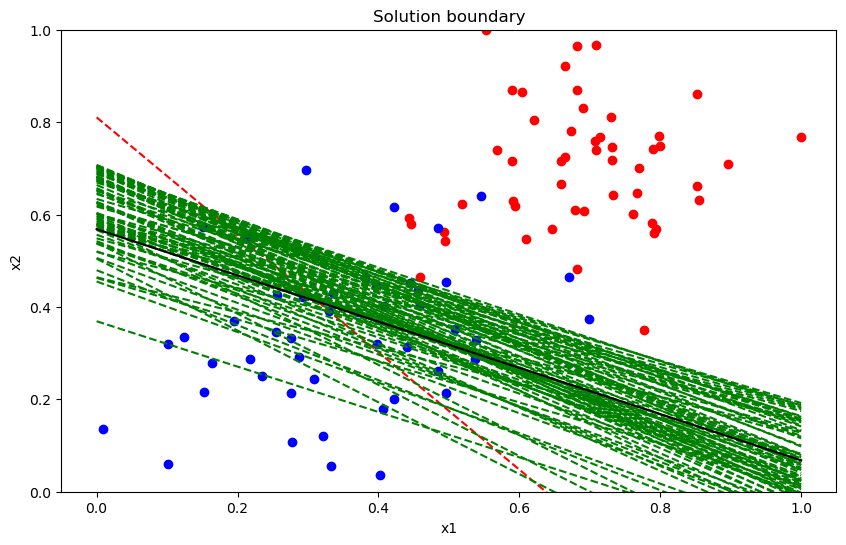

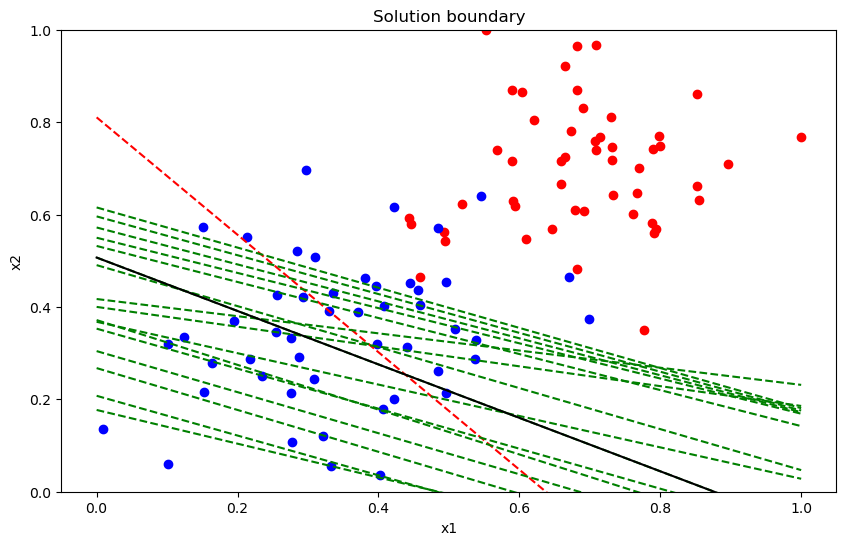

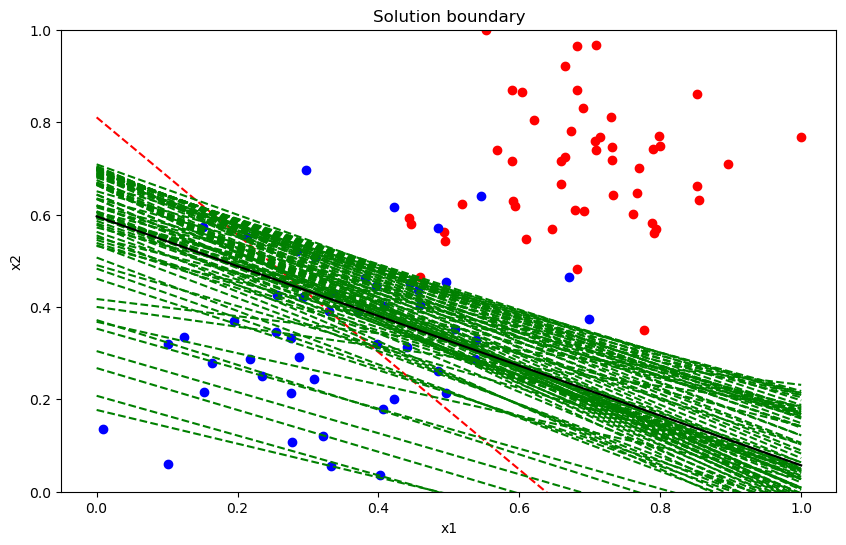

(-5.123399078206592, -9.505331691215199, 5.665145854513334)

In [9]:
#experiment with different learning rate
heuristic(data, learning_rate = 0.05, epochs = 25)
heuristic(data, learning_rate = 0.05, epochs = 75)
heuristic(data, learning_rate = 0.01, epochs = 30)
heuristic(data, learning_rate = 0.01, epochs = 85)
heuristic(data, learning_rate = 0.1, epochs = 25)
heuristic(data, learning_rate = 0.1, epochs = 95)
heuristic(data, learning_rate = 0.5, epochs = 20)
heuristic(data, learning_rate = 0.5, epochs = 80)
heuristic(data, learning_rate = 1, epochs = 16)
heuristic(data, learning_rate = 1, epochs = 86)

In [54]:
#Gradient descent approach
#define sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#define log loss function
def log_loss(y, y_hat):
    epsilon = 1e-9
    return - (y*np.log(y_hat + epsilon) + (1-y)*np.log(1 - y_hat + epsilon))

#implement gradient descent
def gd(data, learning_rate, epochs):
    #ensure reproducibility
    np.random.seed(59)
    w1, w2 = np.random.randn(2)
    b = np.random.randn()
    errors = []
    plt.figure(figsize=(10,6))
    plt.scatter(red["x1"], red["x2"], color="red", label = "class 0")
    plt.scatter(blue["x1"], blue["x2"], color="blue", label = "class 1")
    #initial separation line
    plot_line(w1, w2, b, color="red")
    
    for epoch in range(epochs):
        total_error = 0
        for _, row in data.iterrows():
            x1, x2, y = row["x1"], row["x2"], row["label"]
            #predict
            z = w1*x1 + w2*x2 + b
            y_hat = sigmoid(z)
            error = y - y_hat
            #Gradient update
            w1 += learning_rate * error * x1
            w2 += learning_rate * error * x2
            b  += learning_rate * error
            total_error += log_loss(y, y_hat)
            avg_loss = total_error / len(data)
        errors.append(total_error / len(data))
        #plot
        if epoch % 10 == 0:
            plot_line(w1, w2, b, color="green", linestyle="--")
            print(f"Epoch {epoch}: Average Log Loss = {avg_loss:.4f}")
    #Final line
    plot_line(w1, w2, b, color="black", linestyle="-")
    plt.title("Solution boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.ylim(0,1)
    plt.show()
    return errors
#errors

Epoch 0: Average Log Loss = 0.4425
Epoch 10: Average Log Loss = 0.2970
Epoch 20: Average Log Loss = 0.2336
Epoch 30: Average Log Loss = 0.2052
Epoch 40: Average Log Loss = 0.1890
Epoch 50: Average Log Loss = 0.1786
Epoch 60: Average Log Loss = 0.1713
Epoch 70: Average Log Loss = 0.1659
Epoch 80: Average Log Loss = 0.1618
Epoch 90: Average Log Loss = 0.1586


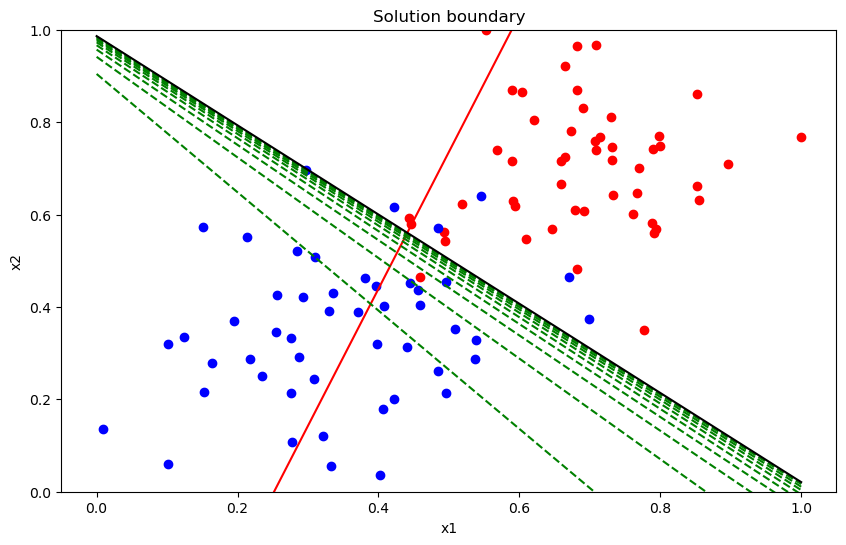

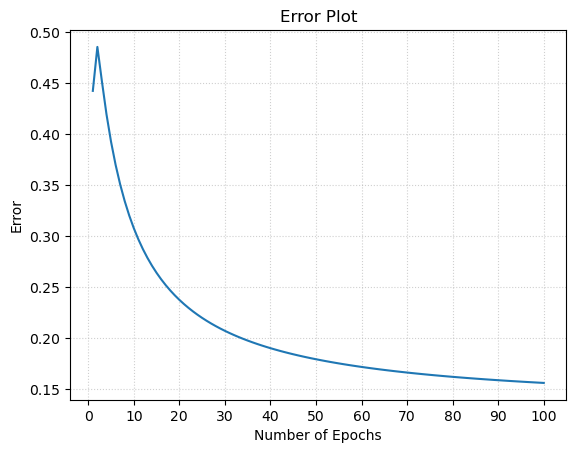

In [55]:
errors = gd(data, learning_rate=0.1, epochs=100)

plt.figure()
plt.plot(range(1, 101), errors)
plt.title("Error Plot")
plt.xlabel("Number of Epochs")
plt.ylabel("Error")
plt.xticks(np.arange(0, 101, 10)) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()